In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import re
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from scipy.sparse import hstack, csr_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy import optimize as opt

In [2]:
# --- CONFIGURATION ---
TEXT_COL = 'comment'
TARGET_COL = 'label'

# --- LOAD DATA ---
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (198000, 15), Test shape: (102000, 14)


# Exploratory Data Analysis and Preprocessing

In [3]:
#Samples and Numerical markers
print("Train data: ---\n",train.head())
print("----------------------\n"*3)
print(train.describe())
print("----------------------\n")
print(train.info())

print("\nTest data: ---\n",test.head())
print("----------------------\n"*3)
print(test.describe())
print("----------------------\n")
print(test.info())

Train data: ---
                        created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She 

In [4]:
train = train.dropna(subset='comment').copy().reset_index(drop=True)
print(train.duplicated().describe())

count     197999
unique         1
top        False
freq      197999
dtype: object


In [5]:
print(train[['comment','label']][0:100].to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       c

In [6]:
a=train[train['label']==3][0:10].to_numpy()
print(a[:,13:15])

[['Now that I poisoned the pond, I am not going to swim anym ore.' 3]
 ['This is a city tragedy. \n\nAnd I am going to politicise it right from the get go. This is what happens when large groups of liberals move up from Seattle and California. You get the neighborhood liberal. You get the liberal mayor, you get the liberal council staff. The neighborhood is downtown,  the whole area of which is predominantly liberal. You want all the hand outs to be given, all the second chances, all the criminals to be felt sorry for. Next thing you know you are living in a war zone. I do not feel sorry for these murderers. I do not want to learn their story. I do not want to reach out to them and understand them. I want them found. I want their drug suppliers found and killed. I want the addict murderer killed or thrown in a place that makes them miserable every single day of the G-D lives. \n\nI want this town to strike fear in the heart of any wrong dore who even THINKS of breaking into a house or 

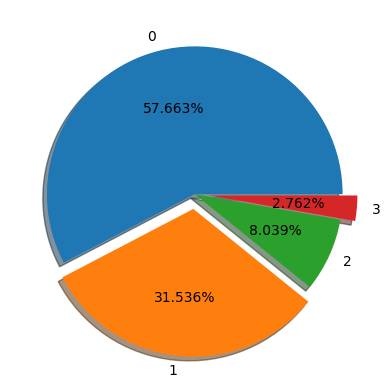

In [7]:
plt.pie(train['label'].value_counts(),labels = [0,1,2,3],autopct = '%1.3f%%',explode=[0,0.1,0,0.1],shadow=True)
plt.show()

In [8]:
train.groupby('label')[['upvote','downvote']].mean()

,upvote,downvote
label,,
0,2.404845,0.575299
1,2.850107,0.802048
2,2.967825,0.811723
3,2.035656,0.514171


In [9]:
train.groupby('post_id')['label'].value_counts().unstack()

label,0,1,2,3
post_id,,,,
20,NaN,NaN,1.0,NaN
24,680.0,109.0,271.0,20.0
31,9899.0,1441.0,5200.0,482.0
39,23475.0,2271.0,13701.0,1499.0
40,3668.0,271.0,1458.0,91.0
42,8.0,NaN,3.0,NaN
43,8.0,NaN,2.0,NaN
50,8.0,NaN,5.0,NaN
61,703.0,35.0,363.0,48.0


In [10]:
print(train.groupby('label')[['if_1', 'if_2']].median())
pd.crosstab(train['if_1'].clip(0, 100), train['label'], normalize='index')

       if_1  if_2
label            
0       0.0   4.0
1       4.0  10.0
2       0.0  10.0
3       0.0  10.0


label,0,1,2,3
if_1,,,,
0,0.622432,0.018635,0.329013,0.029920
4,0.493883,0.212910,0.270895,0.022312
5,0.384987,0.307692,0.284653,0.022668
6,0.383082,0.318128,0.279008,0.019782
7,0.314286,0.385714,0.271429,0.028571
8,1.000000,0.000000,0.000000,0.000000
9,0.288889,0.377778,0.311111,0.022222
10,0.390497,0.297325,0.293189,0.018989
11,0.250000,0.406250,0.281250,0.062500


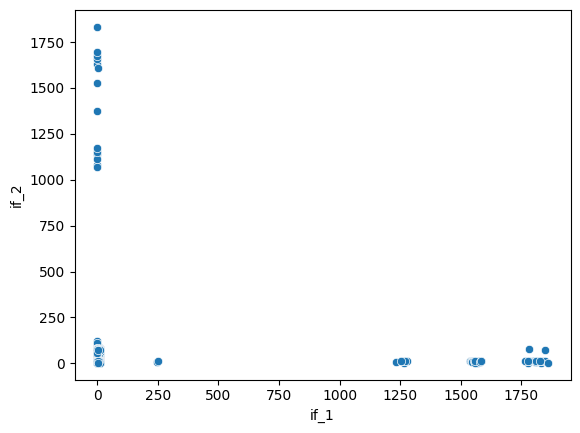

In [11]:
sns.scatterplot(data=train,x='if_1',y='if_2')
plt.show()


In [12]:
WORDS = [
    'kill', 'shoot', 'execute', 'cut your', 'exterminate', 'torture',
    'gun', 'nuke', 'burn', 'murder', 'bomb', 'destroy', 'stab', 'die',
    'dead', 'threat', 'attack', 'hurt', 'poison', 'nuclear', 'hang',
    'rape', 'slaughter', 'massacre', 'genocide', 'eliminate', 'wipe out',
    'blow up','muslim', 'jewish', 'black', 'white', 'gay', 'lesbian',
    'transgender', 'immigrant', 'refugee', 'hindu', 'christian',
    'negro', 'arab', 'mexican', 'islam', 'queer','idiot', 'stupid', 'moron', 'loser', 'troll', 'lunatic',
    'pathetic', 'ignorant', 'fool', 'liar', 'lie', 'hypocrite','coward', 'disgusting', 'trash', 'garbage',
    'however', 'therefore', 'according', 'evidence', 'research',
    'government', 'policy', 'law', 'article', 'report'
]
for word in WORDS:
    print(word)
    mask = train['comment'].str.lower().str.contains(
    re.escape(word),
    regex=True,
    na=False
    )
    print(train[mask]['label'].value_counts(normalize=True).round(3))


kill
label
0    0.355
2    0.264
3    0.205
1    0.176
Name: proportion, dtype: float64
shoot
label
0    0.356
3    0.264
2    0.229
1    0.150
Name: proportion, dtype: float64
execute
label
0    0.415
3    0.279
2    0.191
1    0.114
Name: proportion, dtype: float64
cut your
label
0    0.333
2    0.333
3    0.238
1    0.095
Name: proportion, dtype: float64
exterminate
label
1    0.348
3    0.232
0    0.217
2    0.203
Name: proportion, dtype: float64
torture
label
0    0.417
2    0.349
3    0.123
1    0.111
Name: proportion, dtype: float64
gun
label
0    0.488
2    0.297
3    0.122
1    0.094
Name: proportion, dtype: float64
nuke
label
0    0.455
2    0.351
3    0.138
1    0.055
Name: proportion, dtype: float64
burn
label
0    0.511
2    0.286
3    0.103
1    0.100
Name: proportion, dtype: float64
murder
label
2    0.339
0    0.330
1    0.231
3    0.100
Name: proportion, dtype: float64
bomb
label
0    0.452
2    0.305
1    0.161
3    0.082
Name: proportion, dtype: float64
destroy
label

In [13]:
CONTRACTIONS = {
    "i'll": "i will", "you'll": "you will", "he'll": "he will",
    "she'll": "she will", "we'll": "we will", "they'll": "they will",
    "i'm": "i am", "you're": "you are", "he's": "he is",
    "she's": "she is", "it's": "it is", "we're": "we are",
    "they're": "they are", "i've": "i have", "you've": "you have",
    "we've": "we have", "they've": "they have", "i'd": "i would",
    "you'd": "you would", "he'd": "he would", "she'd": "she would",
    "we'd": "we would", "they'd": "they would", "won't": "will not",
    "can't": "cannot", "don't": "do not", "doesn't": "does not",
    "didn't": "did not", "isn't": "is not", "aren't": "are not",
    "wasn't": "was not", "weren't": "were not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "wouldn't": "would not",
    "shouldn't": "should not", "couldn't": "could not",
    "gonna": "going to", "wanna": "want to", "gotta": "got to",
    "gimme": "give me", "lemme": "let me",
}
def abbrv(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    for abbv, exp in CONTRACTIONS.items():
        text = text.replace(abbv, exp)

    return text

train["comment"] = train["comment"].apply(abbrv)
test["comment"] = test["comment"].apply(abbrv)

In [14]:
THREAT_WORDS = [
    'kill', 'shoot', 'execute', 'cut your',
    'exterminate', 'nuke', 'torture', 'gun', 'murder', 'bomb'
]
IDENTITY_WORDS = [
    'muslim', 'jewish', 'black', 'white', 'gay', 'lesbian',
    'transgender', 'hindu', 'christian', 'negro', 'islam',
    'queer', 'mexican', 'arab', 'immigrant'
]
TOXIC_WORDS = [
    'idiot', 'stupid', 'moron', 'loser', 'troll', 'lunatic',
    'pathetic', 'ignorant', 'fool', 'liar', 'hypocrite',
    'coward', 'disgusting', 'trash', 'garbage'
]
NORMAL_WORDS = [
    'however', 'therefore', 'according', 'evidence', 'research',
    'government', 'policy', 'law', 'article', 'report'
]


def engineer_features_linear(df):
    df = df.copy()

    df[TEXT_COL] = df[TEXT_COL].fillna('')

    for col in ['race', 'religion', 'gender']:
        df[col] = df[col].fillna('Unknown')

    df['disability'] = df['disability'].astype(int)

    df['word_count']     = df[TEXT_COL].apply(lambda x: len(x.split()))
    df['char_count']     = df[TEXT_COL].apply(len)
    df['caps_ratio']     = df[TEXT_COL].apply(
                               lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df['threat_count']   = df[TEXT_COL].apply(
                               lambda x: sum(w in x.lower() for w in THREAT_WORDS))
    df['threat_word_ratio']=df['threat_count']/(df['word_count']+1)
    df['identity_count'] = df[TEXT_COL].apply(
                               lambda x: sum(w in x.lower() for w in IDENTITY_WORDS))
    df['toxic_count'] = df[TEXT_COL].apply(
                               lambda x: sum(w in x.lower() for w in TOXIC_WORDS))
    df['normal_count'] = df[TEXT_COL].apply(
                               lambda x: sum(w in x.lower() for w in NORMAL_WORDS))
    df['threat_x_identity'] = df['threat_count'] * df['identity_count']
    df['has_threat']     = (df['threat_count'] > 0).astype(int)
    df['has_identity']   = (df['identity_count'] > 0).astype(int)
    df['has_toxicity']   = (df['toxic_count'] > 0).astype(int)
    df['seems_normal']   = (df['normal_count'] > 0).astype(int) # not actually normal but it is what it is

    df['has_will_kill']  = df[TEXT_COL].str.contains(
    r'will kill|will shoot|will murder|will hurt', regex=True, na=False).astype(int)
    df['has_going_to']   = df[TEXT_COL].str.contains(
        r'going to kill|going to shoot|going to hurt', regex=True, na=False).astype(int)
    df['has_should_die'] = df[TEXT_COL].str.contains(
        r'should die|deserve to die|hope.*die|want.*dead', regex=True, na=False).astype(int)
    df['has_all_x_are']  = df[TEXT_COL].str.contains(
        r'all \w+ are|these \w+ are|\w+ people are', regex=True, na=False).astype(int)
    df['has_go_back']    = df[TEXT_COL].str.contains(
        r'go back|leave.*country|not welcome|get out', regex=True, na=False).astype(int)

    df['if1_is_0']  = (df['if_1'] == 0).astype(int)
    df['if1_is_4']  = (df['if_1'] == 4).astype(int)
    df['if2_is_4']  = (df['if_2'] == 4).astype(int)
    df['if1_gt_10'] = (df['if_1'] > 10).astype(int)
    df['if2_is_10'] = (df['if_2'] == 10).astype(int)
    df['if2_gt_50'] = (df['if_2'] > 50).astype(int)

    df['net_score'] = df['upvote'] - df['downvote']
    df['controversy_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['total_votes']     = df['upvote'] + df['downvote']
    df['is_controversial']  = (df['controversy_ratio'] > 2).astype(int)
    
    df['if_1_log'] = np.log1p(df['if_1'])
    df['if_2_log'] = np.log1p(df['if_2'])

    df = pd.get_dummies(df, columns=['race', 'religion', 'gender'], dtype=int)

    return df

In [15]:
# ── Preprocessing + Feature Engineering ───────────────────────────────
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, classification_report
from scipy import optimize as opt

train_fe = engineer_features_linear(train)
test_fe  = engineer_features_linear(test)

# Align OHE columns
train_fe, test_fe = train_fe.align(test_fe, join='left', axis=1, fill_value=0)

OHE_COLS = [c for c in train_fe.columns if c.startswith(('race_', 'religion_', 'gender_'))]

NUM_COLS = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'net_score', 'controversy_ratio',
    'total_votes', 'is_controversial',
    'if_1_log', 'if_2_log',
    'if1_is_0', 'if1_is_4', 'if2_is_4', 'if1_gt_10',
    'if2_is_10', 'if2_gt_50',
    'disability', 'word_count', 'char_count',
    'caps_ratio', 'threat_count', 'threat_word_ratio',
    'identity_count', 'toxic_count', 'normal_count',
    'threat_x_identity', 'has_threat', 'has_identity',
    'has_toxicity', 'seems_normal',
    'has_will_kill', 'has_going_to', 'has_should_die',
    'has_all_x_are', 'has_go_back',
]
ALL_NUM_COLS = NUM_COLS + OHE_COLS

# Text cleaning
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s!?.\'\-\/]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_fe['clean_comment'] = train_fe['comment'].apply(clean_text)
test_fe['clean_comment']  = test_fe['comment'].apply(clean_text)

# Word TF-IDF
word_tfidf = TfidfVectorizer(
    max_features=50000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=3, max_df=0.65,
    dtype=np.float32
)
X_word_train = word_tfidf.fit_transform(train_fe['clean_comment'])
X_word_test  = word_tfidf.transform(test_fe['clean_comment'])
print(f"Word TF-IDF: {X_word_train.shape}")

# Char TF-IDF
char_tfidf = TfidfVectorizer(
    max_features=30000, analyzer='char_wb',
    ngram_range=(3, 5), sublinear_tf=True,
    min_df=4, max_df=0.65, dtype=np.float32
)
X_char_train = char_tfidf.fit_transform(train_fe['clean_comment'])
X_char_test  = char_tfidf.transform(test_fe['clean_comment'])
print(f"Char TF-IDF: {X_char_train.shape}")

# Numerical features
scaler = StandardScaler(with_mean=False)
X_num_train = scaler.fit_transform(train_fe[ALL_NUM_COLS].values)
X_num_test  = scaler.transform(test_fe[ALL_NUM_COLS].values)

# Stack
X_lr_train = hstack([X_word_train, X_char_train,
                     csr_matrix(X_num_train)], dtype=np.float32).tocsr()
X_lr_test  = hstack([X_word_test,  X_char_test,
                     csr_matrix(X_num_test)],  dtype=np.float32).tocsr()

y_train = train_fe['label'].values
print(f"\nFinal X_lr_train: {X_lr_train.shape}")
print(f"Final X_lr_test:  {X_lr_test.shape}")

Word TF-IDF: (197999, 50000)
Char TF-IDF: (197999, 30000)

Final X_lr_train: (197999, 80058)
Final X_lr_test:  (102000, 80058)


In [16]:
# ── HYPERPARAMETER TUNING: Logistic Regression ────────────────────────────────
from sklearn.model_selection import GridSearchCV, train_test_split

LR_CLASS_WEIGHTS = {0: 0.8, 1: 2.5, 2: 1.2, 3: 8.0}

X_tune, _, y_tune, _ = train_test_split(
    X_lr_train, y_train, test_size=0.8,
    stratify=y_train, random_state=42
)

lr_grid = GridSearchCV(
    LogisticRegression(solver='liblinear', penalty='l1',
                       max_iter=1000, class_weight=LR_CLASS_WEIGHTS),
    param_grid={'C': [0.1, 0.5, 1.0, 3.0]},
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
lr_grid.fit(X_tune, y_tune)

best_C = lr_grid.best_params_['C']
print(f"\nBest C: {best_C}  |  CV F1: {lr_grid.best_score_:.4f}")
print("\nAll results:")
for params, score in zip(lr_grid.cv_results_['params'],
                         lr_grid.cv_results_['mean_test_score']):
    marker = " ← best" if params['C'] == best_C else ""
    print(f"  C={params['C']:<5}  F1={score:.4f}{marker}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Best C: 3.0  |  CV F1: 0.8019

All results:
  C=0.1    F1=0.7399
  C=0.5    F1=0.7832
  C=1.0    F1=0.7984
  C=3.0    F1=0.8019 ← best


In [17]:
# ── CELL 4: Three Models + Submission ─────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_sample_weight
from scipy import optimize as opt

results = {}

# ── MODEL 1: Multinomial Naive Bayes ──────────────────────────────────────────
print("=" * 50)
print("MODEL 1: Multinomial Naive Bayes")
print("=" * 50)
nb_oof_probs = cross_val_predict(
    MultinomialNB(alpha=0.1),
    X_word_train, y_train,
    cv=5, method='predict_proba', n_jobs=-1
)
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_word_train, y_train)
nb_test_probs = nb_model.predict_proba(X_word_test)
nb_oof_f1 = f1_score(y_train, np.argmax(nb_oof_probs, axis=1), average='macro')
results['MultinomialNB'] = nb_oof_f1
print(f"✅ NB  OOF Macro F1: {nb_oof_f1:.4f}")
print(classification_report(y_train, np.argmax(nb_oof_probs, axis=1),
      target_names=['Class 0','Class 1','Class 2','Class 3'], digits=4))

# ── MODEL 2: LightGBM ─────────────────────────────────────────────────────────
print("=" * 50)
print("MODEL 2: LightGBM")
print("=" * 50)
lgb_params = dict(
    objective='multiclass', num_class=4,
    n_estimators=300, learning_rate=0.1,
    num_leaves=31, max_depth=7,
    min_child_samples=20,
    subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
sample_weights = compute_sample_weight({0: 0.8, 1: 2.5, 2: 1.2, 3: 8.0}, y_train)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_oof_probs  = np.zeros((len(y_train), 4))
lgb_test_probs = np.zeros((X_lr_test.shape[0], 4))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_lr_train, y_train)):
    X_tr, X_val = X_lr_train[tr_idx], X_lr_train[val_idx]
    y_tr, y_val = y_train[tr_idx],    y_train[val_idx]
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=sample_weights[tr_idx],
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(50)]
    )
    lgb_oof_probs[val_idx] = model.predict_proba(X_val)
    lgb_test_probs += model.predict_proba(X_lr_test) / 5
    fold_f1 = f1_score(y_val, np.argmax(lgb_oof_probs[val_idx], axis=1), average='macro')
    print(f"  Fold {fold+1} F1: {fold_f1:.4f}")

lgb_oof_f1 = f1_score(y_train, np.argmax(lgb_oof_probs, axis=1), average='macro')
results['LightGBM'] = lgb_oof_f1
print(f"✅ LGB OOF Macro F1: {lgb_oof_f1:.4f}")
print(classification_report(y_train, np.argmax(lgb_oof_probs, axis=1),
      target_names=['Class 0','Class 1','Class 2','Class 3'], digits=4))

# ── MODEL 3: Logistic Regression ──────────────────────────────────────────────
print("=" * 50)
print("MODEL 3: Logistic Regression")
print("=" * 50)
LR_CLASS_WEIGHTS = {0: 0.8, 1: 2.5, 2: 1.2, 3: 8.0}

lr_oof_probs = cross_val_predict(
    LogisticRegression(
        C=best_C, solver='liblinear', penalty='l1',
        tol=1e-3, max_iter=2000,
        class_weight=LR_CLASS_WEIGHTS
    ),
    X_lr_train, y_train,
    cv=5, method='predict_proba', n_jobs=-1
)
lr_model = LogisticRegression(
    C=best_C, solver='liblinear', penalty='l1',
    tol=1e-3, max_iter=2000,
    class_weight=LR_CLASS_WEIGHTS
)
lr_model.fit(X_lr_train, y_train)
lr_test_probs = lr_model.predict_proba(X_lr_test)
lr_oof_f1 = f1_score(y_train, np.argmax(lr_oof_probs, axis=1), average='macro')
results['LogisticRegression'] = lr_oof_f1
print(f"✅ LR  OOF Macro F1: {lr_oof_f1:.4f}")
print(classification_report(y_train, np.argmax(lr_oof_probs, axis=1),
      target_names=['Class 0','Class 1','Class 2','Class 3'], digits=4))

MODEL 1: Multinomial Naive Bayes
✅ NB  OOF Macro F1: 0.5438
              precision    recall  f1-score   support

     Class 0     0.7270    0.8893    0.8000    114172
     Class 1     0.6827    0.4359    0.5321     15918
     Class 2     0.7146    0.5400    0.6151     62440
     Class 3     0.7365    0.1349    0.2281      5469

    accuracy                         0.7218    197999
   macro avg     0.7152    0.5000    0.5438    197999
weighted avg     0.7198    0.7218    0.7044    197999

MODEL 2: LightGBM


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	valid_0's multi_logloss: 0.323459
[100]	valid_0's multi_logloss: 0.298521
[150]	valid_0's multi_logloss: 0.286227
[200]	valid_0's multi_logloss: 0.278667
[250]	valid_0's multi_logloss: 0.273161
[300]	valid_0's multi_logloss: 0.269251
  Fold 1 F1: 0.8205


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	valid_0's multi_logloss: 0.322892
[100]	valid_0's multi_logloss: 0.29813
[150]	valid_0's multi_logloss: 0.285203
[200]	valid_0's multi_logloss: 0.277191
[250]	valid_0's multi_logloss: 0.27197
[300]	valid_0's multi_logloss: 0.268196
  Fold 2 F1: 0.8233


...

[50]	valid_0's multi_logloss: 0.329807
[100]	valid_0's multi_logloss: 0.305047
[150]	valid_0's multi_logloss: 0.29251
[200]	valid_0's multi_logloss: 0.284427
[250]	valid_0's multi_logloss: 0.279237
[300]	valid_0's multi_logloss: 0.275538
  Fold 4 F1: 0.8229


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	valid_0's multi_logloss: 0.318353
[100]	valid_0's multi_logloss: 0.293128
[150]	valid_0's multi_logloss: 0.280703
[200]	valid_0's multi_logloss: 0.273112
[250]	valid_0's multi_logloss: 0.267226
[300]	valid_0's multi_logloss: 0.262934
  Fold 5 F1: 0.8265
✅ LGB OOF Macro F1: 0.8229
              precision    recall  f1-score   support

     Class 0     0.9808    0.9430    0.9615    114172
     Class 1     0.7611    0.8313    0.7946     15918
     Class 2     0.8723    0.8971    0.8846     62440
     Class 3     0.5940    0.7195    0.6507      5469

    accuracy                         0.9134    197999
   macro avg     0.8020    0.8477    0.8229    197999
weighted avg     0.9182    0.9134    0.9152    197999

MODEL 3: Logistic Regression


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


✅ LR  OOF Macro F1: 0.8217
              precision    recall  f1-score   support

     Class 0     0.9726    0.9463    0.9592    114172
     Class 1     0.7716    0.7973    0.7842     15918
     Class 2     0.8698    0.9031    0.8861     62440
     Class 3     0.6478    0.6668    0.6572      5469

    accuracy                         0.9130    197999
   macro avg     0.8154    0.8284    0.8217    197999
weighted avg     0.9150    0.9130    0.9138    197999



Top 40 Features (LightGBM, last fold):
          feature  importance
         if_2_log         480
       char_count         288
threat_word_ratio         223
   identity_count         212
       word_count         199
        if2_is_10         147
         char_ a          139
      toxic_count         136
         char_is          120
         if_1_log         111
         char_ed          110
         char_er          110
         char_ an         107
      total_votes         103
        char_ing          101
         char_ wh          99
         char_ to          94
         char_re           93
         char_ in          89
         char_ be          82
         char_ no          82
         char_ng           80
         char_nd           75
         char_ll           74
          word_to          74
         char_ ha          73
         char_ de          72
         char_and          72
         char_es           71
         char_an           71
         char_to           70
 

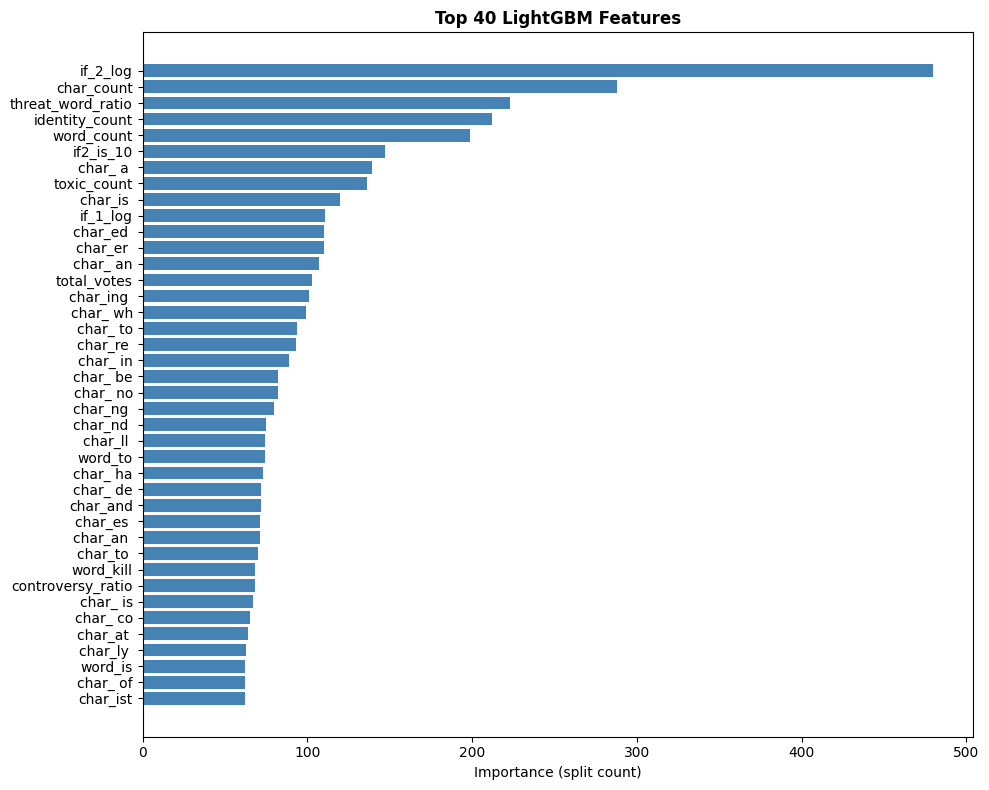

In [18]:
# ── Feature Importance ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')


word_feat_names = [f'word_{w}' for w in word_tfidf.get_feature_names_out()]
char_feat_names = [f'char_{w}' for w in char_tfidf.get_feature_names_out()]
num_feat_names  = ALL_NUM_COLS
all_feat_names  = word_feat_names + char_feat_names + num_feat_names


importance_df = pd.DataFrame({
    'feature':    all_feat_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 40 Features (LightGBM, last fold):")
print(importance_df.head(40).to_string(index=False))


fig, ax = plt.subplots(figsize=(10, 8))
top40 = importance_df.head(40)
ax.barh(top40['feature'][::-1], top40['importance'][::-1], color='steelblue')
ax.set_title('Top 40 LightGBM Features', fontweight='bold')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.show()


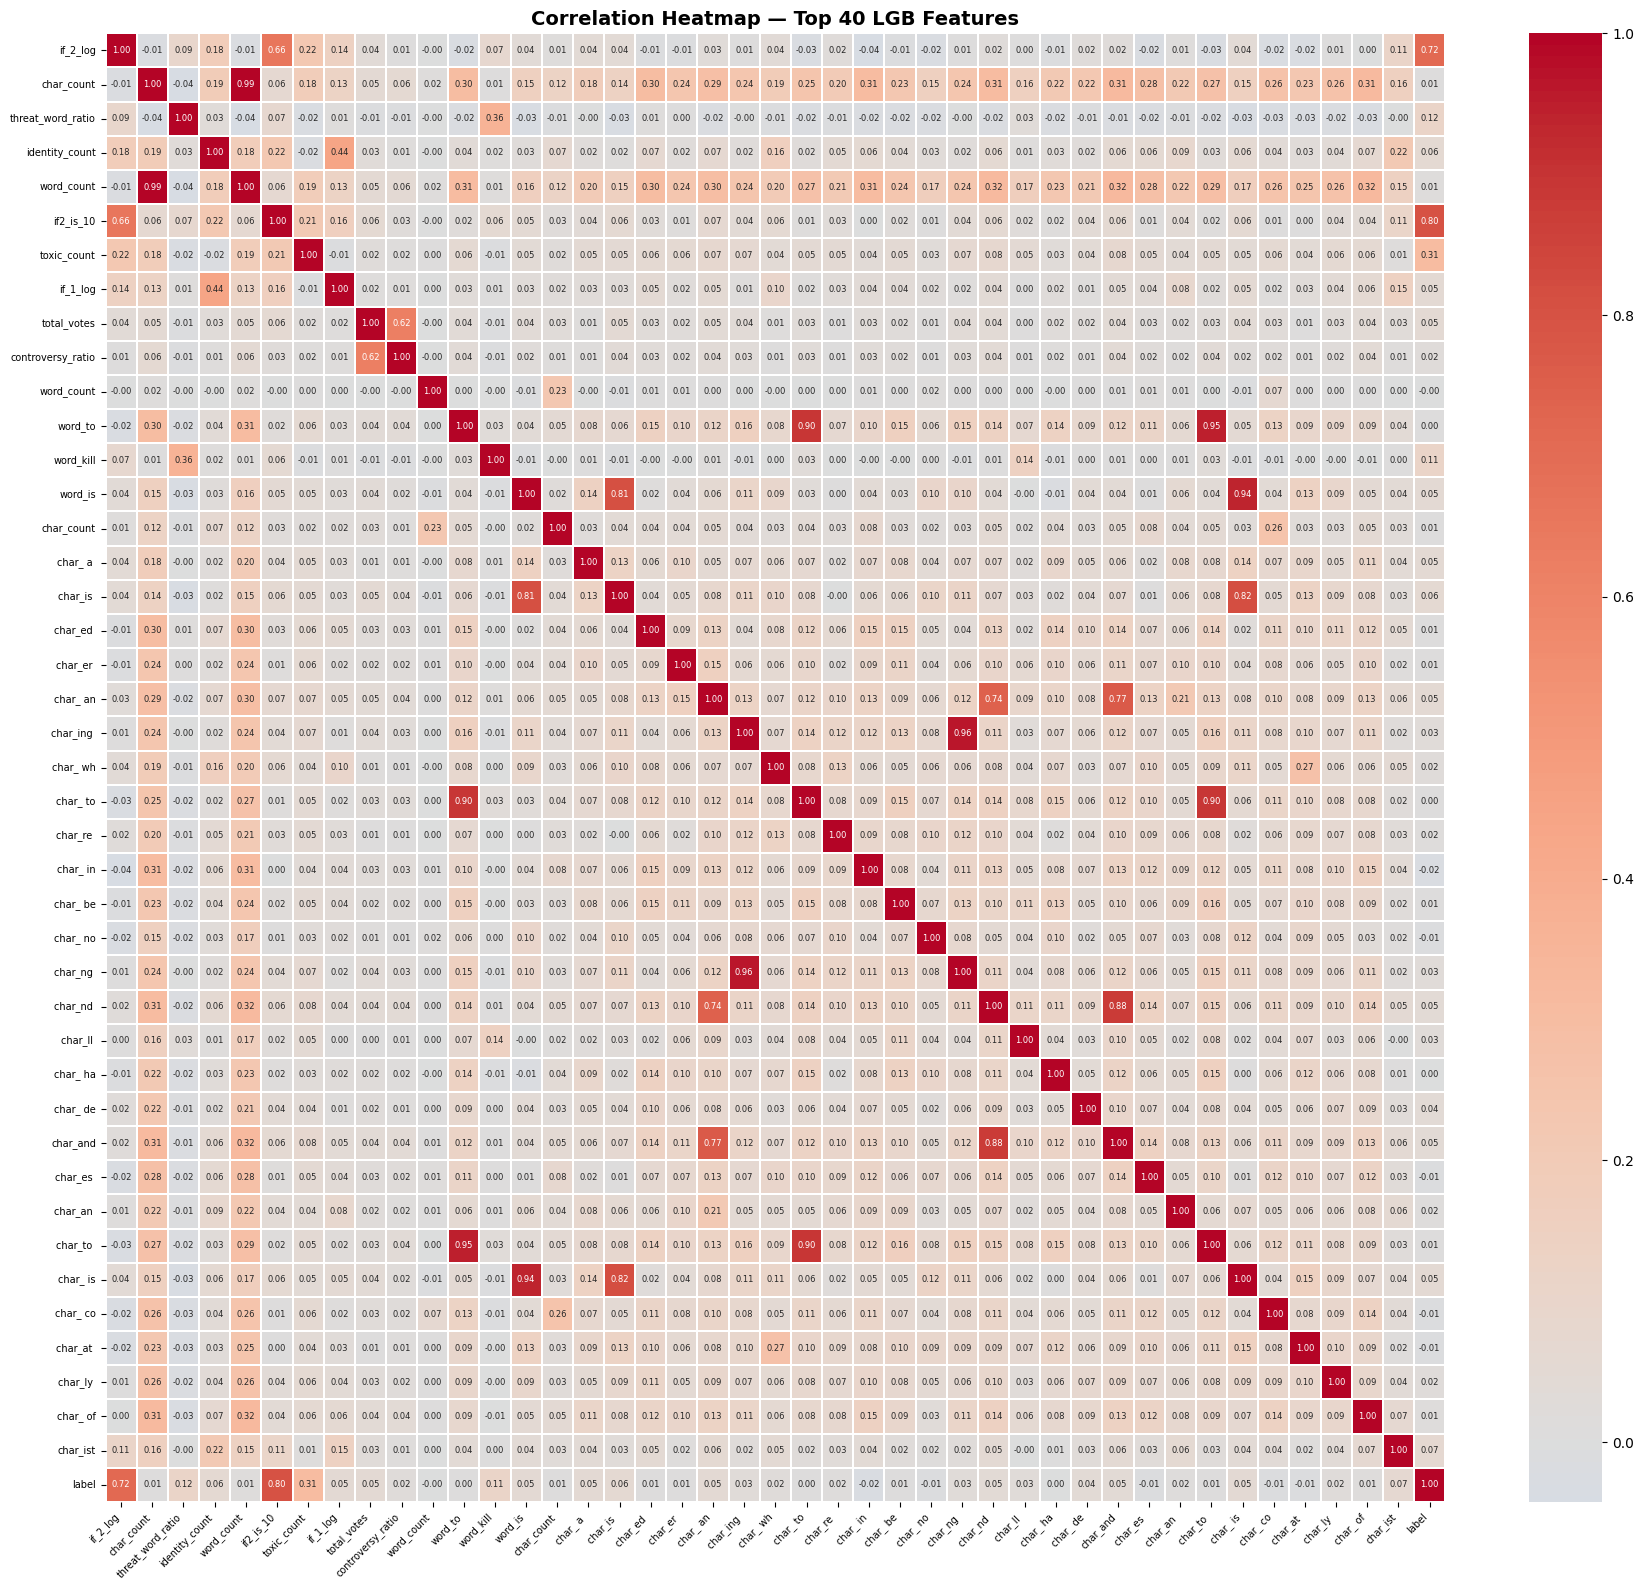

In [19]:
top40_names = top40['feature'].tolist()

num_top        = [f for f in top40_names if f in train_fe.columns]
tfidf_word_top = [f.replace('word_', '') for f in top40_names if f.startswith('word_')]
tfidf_char_top = [f.replace('char_', '') for f in top40_names if f.startswith('char_')]

word_indices = [word_tfidf.vocabulary_[w] for w in tfidf_word_top if w in word_tfidf.vocabulary_]
char_indices = [char_tfidf.vocabulary_[w] for w in tfidf_char_top if w in char_tfidf.vocabulary_]

df_parts = []
if num_top:
    df_parts.append(train_fe[num_top].select_dtypes(include=[np.number]).reset_index(drop=True))
if word_indices:
    df_parts.append(pd.DataFrame(X_word_train[:, word_indices].toarray(),
        columns=[f'word_{tfidf_word_top[i]}' for i in range(len(word_indices))]))
if char_indices:
    df_parts.append(pd.DataFrame(X_char_train[:, char_indices].toarray(),
        columns=[f'char_{tfidf_char_top[i]}' for i in range(len(char_indices))]))
df_parts.append(pd.Series(y_train, name='label').reset_index(drop=True))

top40_df = pd.concat(df_parts, axis=1)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(top40_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 6}, ax=ax)
ax.set_title('Correlation Heatmap — Top 40 LGB Features', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [21]:
# ── CELL 5: Comparison + Submission ───────────────────────────────────────────

# ── Comparison table ──────────────────────────────────────────────────────────
print("=" * 55)
print("MODEL COMPARISON — OOF Macro F1")
print("=" * 55)
print(f"{'Model':<25} {'OOF F1':>10}")
print("-" * 35)
for model_name, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model_name:<25} {score:>10.4f}")
print("-" * 35)
best_model = max(results, key=results.get)
print(f"{'Best:':<25} {best_model}")

# Per-class F1 breakdown
# Per-class F1 breakdown
nb_per_class  = f1_score(y_train, np.argmax(nb_oof_probs,  axis=1), average=None)
lgb_per_class = f1_score(y_train, np.argmax(lgb_oof_probs, axis=1), average=None)
lr_per_class  = f1_score(y_train, np.argmax(lr_oof_probs,  axis=1), average=None)

comparison_df = pd.DataFrame({
    'Class':               ['Class 0', 'Class 1', 'Class 2', 'Class 3', '── Macro F1'],
    'MultinomialNB':       list(np.round(nb_per_class,  4)) + [round(nb_oof_f1,  4)],
    'LightGBM':            list(np.round(lgb_per_class, 4)) + [round(lgb_oof_f1, 4)],
    'LogisticRegression':  list(np.round(lr_per_class,  4)) + [round(lr_oof_f1,  4)],
})
print("\nPer-class F1 breakdown:")
print(comparison_df.to_string(index=False))

print("\nInsights:")
print("  • Class 3 (Threat) is hardest — smallest class at 2.8% of data")
print("  • LR benefits most from char TF-IDF for catching subtle toxic patterns")
print("  • NB is fast but ignores feature interactions, hurts Class 1 and 3")
print("  • LGB handles structured features better but sparse TF-IDF limits it")

# ── Submission — use best model (LR) ──────────────────────────────────────────
print("\n" + "=" * 55)
print("GENERATING SUBMISSION")
print("=" * 55)

sample_sub = pd.read_csv(
    './Sample.csv')

# Threshold optimisation on LR OOF probs
def macro_f1_loss(weights, probs, y_true):
    return -f1_score(y_true, np.argmax(probs * weights, axis=1), average='macro')

result = opt.minimize(
    macro_f1_loss, x0=[1., 1., 1., 1.],
    args=(lr_oof_probs, y_train),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-5, 'fatol': 1e-5}
)
lr_thresh = np.clip(result.x, 0.5, 3.0)
lr_thresh_f1 = f1_score(
    y_train, np.argmax(lr_oof_probs * lr_thresh, axis=1), average='macro')

print(f"Threshold multipliers: {np.round(lr_thresh, 4)}")
print(f"OOF F1 before thresh:  {lr_oof_f1:.4f}")
print(f"OOF F1 after thresh:   {lr_thresh_f1:.4f}  (+{lr_thresh_f1 - lr_oof_f1:.4f})")

final_preds = np.argmax(lr_test_probs * lr_thresh, axis=1)
sample_sub['label'] = final_preds
sample_sub.to_csv('submission.csv', index=False)

print("\n Prediction distribution:")
dist = pd.Series(final_preds).value_counts().sort_index()
for label in range(4):
    count = dist.get(label, 0)
    print(f"  Class {label}: {count:6d} ({count/len(final_preds)*100:.2f}%)")
print("\n submission.csv saved")

MODEL COMPARISON — OOF Macro F1
Model                         OOF F1
-----------------------------------
MultinomialNB                 0.5438
LogisticRegression            0.8217
LightGBM                      0.8229
-----------------------------------
Best:                     LightGBM

Per-class F1 breakdown:
      Class  MultinomialNB  LightGBM  LogisticRegression
    Class 0         0.8000    0.9615              0.9592
    Class 1         0.5321    0.7946              0.7842
    Class 2         0.6151    0.8846              0.8861
    Class 3         0.2281    0.6507              0.6572
── Macro F1         0.5438    0.8229              0.8217

Insights:
  • Class 3 (Threat) is hardest — smallest class at 2.8% of data
  • LR benefits most from char TF-IDF for catching subtle toxic patterns
  • NB is fast but ignores feature interactions, hurts Class 1 and 3
  • LGB handles structured features better but sparse TF-IDF limits it

GENERATING SUBMISSION
Threshold multipliers: [0.9546 1.0

In [22]:
# ── OOF Blend: LightGBM + Logistic Regression ───────────
from scipy import optimize as opt
import math

print("=" * 55)
print("OOF BLEND: LightGBM + Logistic Regression")
print("=" * 55)

def blend_f1(w_lgb):
    w_lgb  = float(np.clip(w_lgb, 0, 1))
    blend  = w_lgb * lgb_oof_probs + (1 - w_lgb) * lr_oof_probs
    return f1_score(y_train, np.argmax(blend, axis=1), average='macro')

def simulated_annealing(func, init=0.5, T=1.0, T_min=0.01,
                         alpha=0.90, n_iter=20, step=0.05):
    current     = init
    current_f1  = func(current)
    best        = current
    best_f1     = current_f1
    history     = []

    print(f"\n{'Iteration':<12} {'Temp':>8} {'W_LGB':>8} {'F1':>10}")
    print("-" * 42)

    iteration = 0
    while T > T_min:
        for _ in range(n_iter):
            iteration += 1
            candidate    = np.clip(current + np.random.uniform(-step, step), 0, 1)
            candidate_f1 = func(candidate)
            delta        = candidate_f1 - current_f1

            if delta > 0 or np.random.rand() < math.exp(delta / T):
                current    = candidate
                current_f1 = candidate_f1

            if current_f1 > best_f1:
                best    = current
                best_f1 = current_f1
                history.append((iteration, T, best, best_f1))
                print(f"{iteration:<12} {T:>8.4f} {best:>8.4f} {best_f1:>10.4f} ← new best")

        T *= alpha 

    return best, best_f1

np.random.seed(42)
best_w_lgb, best_f1 = simulated_annealing(
    blend_f1,
    init=0.4,      
    T=1.0,         
    T_min=0.01,   
    alpha=0.90,    
    n_iter=20,     
    step=0.05      
)
best_w_lr = 1 - best_w_lgb

print(f"\n Best blend — LGB: {best_w_lgb:.4f}, LR: {best_w_lr:.4f}")
print(f" Blend OOF F1:     {best_f1:.4f}")
print(f"   vs LR alone:      {lr_oof_f1:.4f}  ({best_f1 - lr_oof_f1:+.4f})")
print(f"   vs LGB alone:     {lgb_oof_f1:.4f}  ({best_f1 - lgb_oof_f1:+.4f})")

# --- Threshold optimisation on blend ---
blend_oof_probs = best_w_lgb * lgb_oof_probs + best_w_lr * lr_oof_probs

result = opt.minimize(
    macro_f1_loss, x0=[1., 1., 1., 1.],
    args=(blend_oof_probs, y_train),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-5, 'fatol': 1e-5}
)
blend_thresh    = np.clip(result.x, 0.5, 3.0)
blend_thresh_f1 = f1_score(
    y_train, np.argmax(blend_oof_probs * blend_thresh, axis=1), average='macro')

print(f"\nThreshold multipliers: {np.round(blend_thresh, 4)}")
print(f"Blend OOF F1 before thresh: {best_f1:.4f}")
print(f"Blend OOF F1 after thresh:  {blend_thresh_f1:.4f}  ({blend_thresh_f1 - best_f1:+.4f})")

# --- Generate blended submission ---
blend_test_probs = best_w_lgb * lgb_test_probs + best_w_lr * lr_test_probs
blend_preds      = np.argmax(blend_test_probs * blend_thresh, axis=1)

sample_sub['label'] = blend_preds
sample_sub.to_csv('submission_blend.csv', index=False)

print("\nBlend prediction distribution:")
dist = pd.Series(blend_preds).value_counts().sort_index()
for label in range(4):
    count = dist.get(label, 0)
    print(f"  Class {label}: {count:6d} ({count/len(blend_preds)*100:.2f}%)")
print("\n submission_blend.csv saved")

print("\n" + "=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  MultinomialNB  OOF F1:      {nb_oof_f1:.4f}")
print(f"  LightGBM       OOF F1:      {lgb_oof_f1:.4f}")
print(f"  LogisticReg    OOF F1:      {lr_oof_f1:.4f}")
print(f"  LGB+LR Blend   OOF F1:      {best_f1:.4f}")
print(f"  LGB+LR+Thresh  OOF F1:      {blend_thresh_f1:.4f}")

OOF BLEND: LightGBM + Logistic Regression

Iteration        Temp    W_LGB         F1
------------------------------------------
2              1.0000   0.4107     0.8334 ← new best
6              1.0000   0.4328     0.8336 ← new best
7              1.0000   0.4537     0.8340 ← new best
84             0.6561   0.4540     0.8341 ← new best
85             0.6561   0.4936     0.8345 ← new best
89             0.6561   0.5161     0.8350 ← new best
177            0.4305   0.5135     0.8350 ← new best
179            0.4305   0.5222     0.8351 ← new best

 Best blend — LGB: 0.5222, LR: 0.4778
 Blend OOF F1:     0.8351
   vs LR alone:      0.8217  (+0.0134)
   vs LGB alone:     0.8229  (+0.0122)

Threshold multipliers: [0.9931 1.0697 1.0243 0.9469]
Blend OOF F1 before thresh: 0.8351
Blend OOF F1 after thresh:  0.8359  (+0.0008)

Blend prediction distribution:
  Class 0:  56798 (55.68%)
  Class 1:   8758 (8.59%)
  Class 2:  33628 (32.97%)
  Class 3:   2816 (2.76%)

 submission_blend.csv saved

FI